# Modelo de Clasificación mediante Regresión Logística Multinomial para la predicción de niveles de TCH y Sacarosa en la industria azucarera

Este cuaderno tiene como objetivo desarrollar un modelo de clasificación basado en regresión logística multinomial para predecir los niveles de productividad de la caña de azúcar, específicamente el TCH (Toneladas de Caña por Hectárea) y el contenido de sacarosa.

Para ello, se utilizan datos históricos suministrados por el Ingenio Providencia, los cuales contienen información agronómica y de manejo del cultivo. Las variables continuas de interés (TCH y sacarosa) son transformadas en categorías (Bajo, Medio y Alto), permitiendo abordar el problema como una tarea de clasificación multiclase.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.preprocessing import imputar_datos, create_target_classes
from src.evaluation import evaluar_modelo

# Definición de rutas base a los archivos de datos los Raw
RAW_DATA_PATH_1 = '../data/BD_IPSA_1940.xlsx'
RAW_DATA_PATH_2 = '../data/HISTORICO_SUERTES.xlsx'
PROCESSED_DATA_PATH = '../data/processed/datos_limpios_modelo.csv'

## 2. Carga y Exploración Inicial de Datos

In [2]:
df = pd.read_excel(RAW_DATA_PATH_1)
df.head()

,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


A continuación se carga el dataset BD_IPSA_1940, el cual contiene información histórica sobre variables agronómicas, ambientales y de manejo del cultivo de caña de azúcar. Este conjunto de datos será utilizado para entrenar y evaluar los modelos de clasificación.

## 3. Creación de clases para variables objetivo (TCH y sacarosa)

Para facilitar el modelado de clasificación, las variables continuas TCH y sacarosa se discretizaron en tres clases: Bajo, Medio y Alto.

En ambos casos se utilizó discretización basada en cuantiles (`pd.qcut`), lo que permite generar clases con una distribución más equilibrada. Esto se utilizó con el objetivo de evitar problemas de desbalance de clases, los cuales pueden afectar negativamente el desempeño de los modelos de clasificación.

Esta transformación convierte el problema de regresión en uno de clasificación multiclase.

In [3]:
# Clasificación de TCH
df["TCH_clase"] = pd.qcut(
    df["TCH"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)
# Clasificación de sacarosa
df["sacarosa_clase"] = pd.qcut(
    df["sacarosa"],
    q=3,
    labels=["Bajo", "Medio", "Alto"],
    duplicates='drop'
)

## 4. Definición de las variables predictoras

En esta sección se seleccionan las variables predictoras que serán utilizadas por el modelo. La elección se basa en su relevancia agronómica y en su posible relación con el rendimiento y la calidad del cultivo de caña de azúcar.

Se incluyen variables asociadas al desarrollo del cultivo, condiciones climáticas, manejo agronómico y características del lote, ya que estas pueden influir tanto en el TCH como en el contenido de sacarosa.

In [4]:
features = [
    "edad", "cortes", "dosismad", "semsmad",
    "lluvias", "pct_diatrea", "vejez",
    "tipocorte", "variedad", "madurada",
    "producto", "mes", "periodo", "grupo_tenencia"
]

Las variables seleccionadas permiten representar distintos factores que afectan el comportamiento del cultivo. Por ejemplo, `edad`, `cortes` y `vejez` reflejan el estado de desarrollo de la caña; `lluvias` captura condiciones climáticas; `dosismad` y `semsmad` representan manejo agronómico; mientras que `variedad`, `tipocorte` y `grupo_tenencia` permiten incorporar diferencias estructurales entre los registros.

## 5. Creación de subconjuntos para TCH y sacarosa

Dado que el laboratorio plantea dos problemas de clasificación diferentes, se construyen dos subconjuntos a partir del mismo dataset base: uno para la predicción de `TCH_clase` y otro para la predicción de `sacarosa_clase`.

Aunque ambos modelos utilizan el mismo conjunto de variables predictoras, cada uno requiere una variable objetivo distinta. Por esta razón, se generan subconjuntos separados para garantizar claridad en el flujo de modelamiento y evitar confusiones durante el entrenamiento y la evaluación.

In [5]:
data_tch = df[features + ["TCH_clase"]].dropna(subset=["TCH_clase"]).copy()
data_sac = df[features + ["sacarosa_clase"]].dropna(subset=["sacarosa_clase"]).copy()

En este paso se eliminan las filas en las que la variable objetivo no está disponible. Este procedimiento debe realizarse antes de la partición entre entrenamiento y prueba, ya que la variable `y` no puede contener valores nulos al momento de aplicar `train_test_split` ni durante el entrenamiento del modelo.

## 6. Modelado y Análisis para la Predicción de TCH

### 6.1. Definición de Características (X) y Variable Objetivo (y) para TCH

Se seleccionan las columnas que se utilizarán como características (`features`) para el modelo y se define `TCH_clase` como la variable objetivo (`y`). Posteriormente, los datos se dividen en conjuntos de entrenamiento y prueba utilizando `train_test_split` con una proporción del 80% para entrenamiento y 20% para prueba. `stratify=y` asegura que la distribución de las clases de la variable objetivo sea similar en ambos conjuntos.

In [6]:
X = data_tch[features]
y = data_tch["TCH_clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

El conjunto de prueba se separa desde el inicio y se reserva exclusivamente para la evaluación final del modelo. Esto garantiza que el modelo no tenga acceso a estos datos durante el entrenamiento, permitiendo medir de forma más realista su capacidad de generalización ante datos nuevos.

### 6.2. Preprocesamiento de Datos: Transformadores Numéricos y Categóricos

Esta sección define los pasos de preprocesamiento para las características numéricas y categóricas. Se utilizan `SimpleImputer` para manejar valores faltantes y `StandardScaler` para escalar características numéricas, y `OneHotEncoder` para convertir características categóricas en un formato numérico adecuado para el modelo.

In [ ]:
numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numericas),
    ("cat", categorical_transformer, categoricas)
])

Este enfoque permite integrar el preprocesamiento dentro del pipeline del modelo, evitando fugas de información (data leakage) y asegurando que las transformaciones se apliquen correctamente tanto en entrenamiento como en prueba.

### 6.3. Creación del Pipeline del Modelo Base (Regresión Logística)

Se construye un `Pipeline` que encadena el preprocesamiento definido anteriormente (`preprocessor`) con un modelo de `LogisticRegression`. Se configuran algunos parámetros del modelo como `multi_class`, `solver` y `max_iter`.

In [8]:
pipe_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="saga",
        max_iter=5000
    ))
])

Se utiliza el solver `saga`, ya que permite trabajar con regularización L1 y L2 en problemas multiclase. Además, se incrementa el número de iteraciones (`max_iter`) para asegurar la convergencia del modelo.

### 6.4. Configuración de la Búsqueda de Hiperparámetros con GridSearchCV

Se define una estrategia de validación cruzada (`StratifiedKFold`) para asegurar una representación equitativa de las clases en cada pliegue. También se especifica una cuadrícula de hiperparámetros (`param_grid`) para el modelo de Regresión Logística, que incluye diferentes valores para la regularización (`penalty`) y el parámetro de fuerza de regularización (`C`). Finalmente, se configura `GridSearchCV` para buscar la mejor combinación de hiperparámetros.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

La validación cruzada se aplica únicamente sobre el conjunto de entrenamiento, lo que permite seleccionar los mejores hiperparámetros sin sesgar la evaluación final del modelo.

### 6.5. Entrenamiento del Modelo y Selección de los Mejores Hiperparámetros para TCH

Se entrena el modelo utilizando `GridSearchCV` sobre el conjunto de entrenamiento (`X_train`, `y_train`). Después del entrenamiento, se muestran los mejores hiperparámetros encontrados y el mejor puntaje de F1 macro obtenido durante la validación cruzada.

Antes del entrenamiento, se analiza la distribución de las clases con el fin de identificar posibles desbalances que puedan afectar el desempeño del modelo.

In [10]:
print("Distribución de clases TCH:")
print(data_tch["TCH_clase"].value_counts(dropna=False))

Distribución de clases TCH:
TCH_clase
Bajo     754
Alto     728
Medio    705
Name: count, dtype: int64


Como podemos ver, las clases del TCH se encuentran lo suficientemente balancedas 

A continuación, se procede al entrenamiento del modelo:

In [ ]:
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

### 6.6. Resultados de la búsqueda de hiperparámetros para TCH

La búsqueda de hiperparámetros realizada mediante `GridSearchCV` permitió identificar como mejor configuración una penalización `l1` con un valor de regularización `C = 0.1`. Esta combinación obtuvo un puntaje de **F1 macro de 0.4439** durante la validación cruzada, lo que indica un desempeño moderado del modelo sobre el conjunto de entrenamiento.

El valor seleccionado de `C` sugiere que una regularización relativamente fuerte ayuda a controlar la complejidad del modelo, mientras que la penalización `l1` favorece una selección implícita de variables al reducir la influencia de predictores menos relevantes.

### 6.7. Evaluación del Modelo en el Conjunto de Prueba para TCH

Una vez seleccionado el mejor modelo, se realizan predicciones sobre el conjunto de prueba (`X_test`) y se evalúa su rendimiento utilizando métricas como la exactitud (Accuracy), el F1 Macro y un reporte de clasificación detallado.

In [12]:
y_pred = best_model.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred))
print("F1 Macro en test:", f1_score(y_test, y_pred, average="macro"))
print("\nReporte de clasificación en test:")
print(classification_report(y_test, y_pred))

Accuracy en test: 0.4611872146118721
F1 Macro en test: 0.4424390938753344

Reporte de clasificación en test:
              precision    recall  f1-score   support

        Alto       0.50      0.62      0.56       146
        Bajo       0.47      0.53      0.50       151
       Medio       0.35      0.22      0.27       141

    accuracy                           0.46       438
   macro avg       0.44      0.46      0.44       438
weighted avg       0.44      0.46      0.45       438



El modelo presenta un F1 macro moderado, lo cual indica un desempeño limitado en la clasificación de las tres clases. Se observa que la clase "Alto" presenta el mejor rendimiento, seguida de la clase "Bajo", mientras que la clase "Medio" presenta el desempeño más bajo. Esto sugiere que la categoría intermedia tiene un alto solapamiento con las clases extremas, dificultando su correcta separación por parte del modelo.

Este comportamiento indica que las clases no son completamente separables en el espacio de características, lo cual limita el desempeño del modelo lineal.

### 6.8. Visualización de la Matriz de Confusión para TCH

La matriz de confusión proporciona una representación visual del rendimiento del algoritmo de clasificación, mostrando el número de predicciones correctas e incorrectas para cada clase.

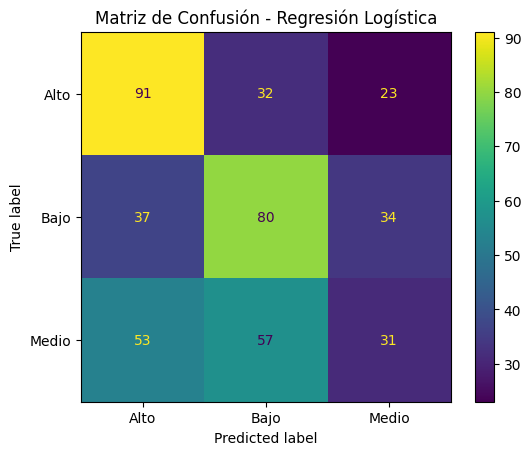

In [13]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

La matriz de confusión muestra que el modelo presenta mejor desempeño en la clase "Alto" y un desempeño aceptable en la clase "Bajo". Sin embargo, la clase "Medio" presenta una alta tasa de confusión con las otras dos categorías, lo que evidencia dificultades del modelo para separar adecuadamente esta clase intermedia.

### 6.9. Análisis de Importancia de Características para TCH

Se extraen los coeficientes del modelo de Regresión Logística para identificar qué características son más influyentes en la predicción de las clases de TCH. La importancia se calcula como el promedio del valor absoluto de los coeficientes para cada característica a través de las diferentes clases.

In [14]:
pre = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

feature_names = pre.get_feature_names_out()

coef_df = pd.DataFrame(
    model.coef_.T,
    index=feature_names,
    columns=model.classes_
)

importancia = coef_df.abs().mean(axis=1).sort_values(ascending=False)
importancia.head(15)

num__cortes                                         0.146289
num__periodo                                        0.122921
num__grupo_tenencia                                 0.087165
num__semsmad                                        0.073665
num__pct_diatrea                                    0.061519
num__edad                                           0.050468
num__vejez                                          0.046070
num__mes                                            0.018345
num__dosismad                                       0.010868
num__lluvias                                        0.002404
cat__tipocorte_Mecanizado Verde                     0.000000
cat__variedad_CC01-1940                             0.000000
cat__madurada_SI                                    0.000000
cat__producto_BONUS 250 EC REGULADOR FISIOLÓGICO    0.000000
dtype: float64

Las variables con mayor importancia incluyen edad, lluvias y variedad, lo cual es consistente con el comportamiento agronómico del cultivo de caña de azúcar.

La edad del cultivo influye directamente en el rendimiento y acumulación de biomasa, mientras que las lluvias afectan el crecimiento vegetativo. Por su parte, la variedad determina características genéticas que impactan tanto la productividad como la calidad del cultivo.

La regularización L1 permitió reducir la influencia de algunas variables menos relevantes, facilitando una forma implícita de selección de variables.

Esto demuestra que el modelo captura relaciones coherentes con el conocimiento agronómico, lo cual valida su interpretabilidad.

## 7. Modelado y Análisis para la Predicción de Sacarosa

### 7.1. Definición de Características (X) y Variable Objetivo (y) para Sacarosa

En esta sección se redefine la variable objetivo como `sacarosa_clase`, manteniendo el mismo conjunto de variables predictoras utilizado en el modelo de TCH. De esta manera, se asegura la comparabilidad entre ambos modelos.

Posteriormente, los datos se dividen en conjuntos de entrenamiento (80%) y prueba (20%) utilizando `train_test_split`, manteniendo la proporción de clases mediante `stratify=y`.

In [15]:
X_sacarosa = data_sac[features]
y_sacarosa = data_sac["sacarosa_clase"]

X_train_sacarosa, X_test_sacarosa, y_train_sacarosa, y_test_sacarosa = train_test_split(
    X_sacarosa,
    y_sacarosa,
    test_size=0.2,
    random_state=42,
    stratify=y_sacarosa
)

### 7.2. Re-entrenamiento del Modelo de Regresión Logística con Sacarosa

Se reentrena el modelo de regresión logística utilizando `GridSearchCV`, manteniendo la misma estructura de pipeline, validación cruzada y espacio de búsqueda de hiperparámetros. Esto permite evaluar si la configuración óptima encontrada para TCH también es adecuada para la predicción de sacarosa o si existen diferencias significativas.

In [ ]:
grid_sacarosa = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

grid_sacarosa.fit(X_train_sacarosa, y_train_sacarosa)

best_model_sacarosa = grid_sacarosa.best_estimator_

print("Mejores hiperparámetros para Sacarosa:", grid_sacarosa.best_params_)
print("Mejor score CV para Sacarosa:", grid_sacarosa.best_score_)

#### Análisis de los Mejores Hiperparámetros para Sacarosa

El entrenamiento del modelo para `sacarosa_clase` ha identificado los hiperparámetros óptimos que se muestran arriba. Los resultados obtenidos permiten analizar si la misma configuración de regularización es adecuada para ambas variables objetivo. Diferencias en los hiperparámetros óptimos pueden indicar que la relación entre las variables predictoras y cada objetivo presenta características distintas.

### 7.3. Evaluación del Modelo de Sacarosa en el Conjunto de Prueba

Se evalúa el rendimiento del modelo en el conjunto de prueba para `sacarosa_clase`.

In [17]:
y_pred_sacarosa = best_model_sacarosa.predict(X_test_sacarosa)

print("Accuracy en test (Sacarosa):", accuracy_score(y_test_sacarosa, y_pred_sacarosa))
print("F1 Macro en test (Sacarosa):", f1_score(y_test_sacarosa, y_pred_sacarosa, average="macro"))
print("\nReporte de clasificación en test (Sacarosa):")
print(classification_report(y_test_sacarosa, y_pred_sacarosa))

Accuracy en test (Sacarosa): 0.4269406392694064
F1 Macro en test (Sacarosa): 0.40174389413349637

Reporte de clasificación en test (Sacarosa):
              precision    recall  f1-score   support

        Alto       0.43      0.63      0.51       143
        Bajo       0.47      0.48      0.48       153
       Medio       0.31      0.16      0.21       142

    accuracy                           0.43       438
   macro avg       0.41      0.43      0.40       438
weighted avg       0.41      0.43      0.40       438



#### Análisis de la Evaluación del Modelo para Sacarosa

Observamos las métricas de `Accuracy` y `F1 Macro` para la predicción de sacarosa. Es crucial comparar estos valores con los del modelo de TCH para determinar si el modelo de regresión logística se desempeña mejor o peor al predecir la sacarosa. El reporte de clasificación ofrece una visión detallada del rendimiento por clase (`Precision`, `Recall`, `F1-Score`), lo que nos permite identificar si hay sesgos en la predicción de alguna de las clases de sacarosa.

A partir de estas métricas, se puede identificar el desempeño del modelo en cada una de las clases. Es importante prestar especial atención al F1-score, ya que permite evaluar el equilibrio entre precisión y recall, especialmente en escenarios donde puede existir solapamiento entre clases.

### 7.4. Visualización de la Matriz de Confusión para Sacarosa

La matriz de confusión para `sacarosa_clase` nos ayuda a entender visualmente dónde el modelo acierta y dónde se equivoca.

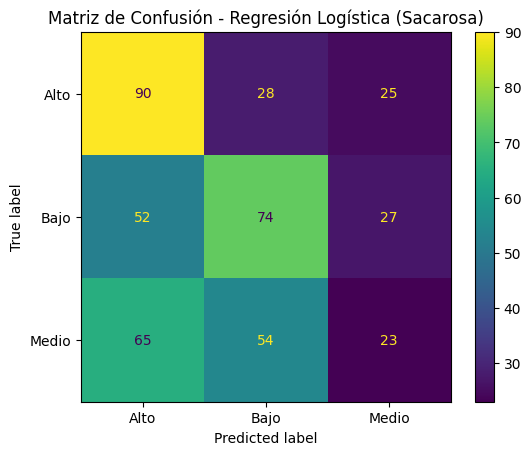

In [18]:
ConfusionMatrixDisplay.from_estimator(best_model_sacarosa, X_test_sacarosa, y_test_sacarosa)
plt.title("Matriz de Confusión - Regresión Logística (Sacarosa)")
plt.show()

Al igual que con TCH, la matriz de confusión para sacarosa revela las fortalezas y debilidades del modelo. Es importante observar si las clases 'Bajo', 'Medio' y 'Alto' son bien diferenciadas o si el modelo tiende a confundirlas, especialmente en las categorías extremas. Comparar este patrón con la matriz de TCH nos dará una mejor perspectiva sobre la complejidad de predecir cada una de las variables objetivo.

### 7.5. Análisis de Importancia de Características para Sacarosa

Se extraen los coeficientes del modelo de Regresión Logística para identificar las características más influyentes en la predicción de las clases de sacarosa.

In [19]:
pre_sacarosa = best_model_sacarosa.named_steps["preprocessor"]
model_sacarosa = best_model_sacarosa.named_steps["model"]

feature_names_sacarosa = pre_sacarosa.get_feature_names_out()

coef_df_sacarosa = pd.DataFrame(
    model_sacarosa.coef_.T,
    index=feature_names_sacarosa,
    columns=model_sacarosa.classes_
)

importancia_sacarosa = coef_df_sacarosa.abs().mean(axis=1).sort_values(ascending=False)
importancia_sacarosa.head(15)

num__lluvias                                        0.229837
num__semsmad                                        0.220683
num__mes                                            0.087043
num__grupo_tenencia                                 0.071013
num__pct_diatrea                                    0.070931
num__vejez                                          0.064765
num__periodo                                        0.050628
num__edad                                           0.038130
num__cortes                                         0.027844
num__dosismad                                       0.017447
cat__tipocorte_Mecanizado Verde                     0.003948
cat__variedad_CC01-1940                             0.003948
cat__madurada_SI                                    0.003948
cat__producto_BONUS 250 EC REGULADOR FISIOLÓGICO    0.003948
dtype: float64

Este análisis nos muestra qué características son más relevantes para predecir los niveles de sacarosa. Al comparar esta lista con la importancia de características para TCH, podemos identificar factores que influyen de manera similar en ambas productividades o aquellos que tienen un impacto diferenciado. Esto puede proporcionar información valiosa sobre la agronomía del cultivo y ayudar a futuras mejoras.

In [20]:
resumen = pd.DataFrame({
    "Objetivo": ["TCH", "Sacarosa"],
    "Mejor_CV_F1_macro": [grid.best_score_, grid_sacarosa.best_score_],
    "Test_Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_sacarosa, y_pred_sacarosa)
    ],
    "Test_F1_macro": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test_sacarosa, y_pred_sacarosa, average="macro")
    ]
})

resumen

,Objetivo,Mejor_CV_F1_macro,Test_Accuracy,Test_F1_macro
0,TCH,0.443931,0.461187,0.442439
1,Sacarosa,0.424732,0.426941,0.401744


La comparación entre ambos modelos permite identificar cuál variable objetivo es más fácil de clasificar utilizando regresión logística. Diferencias en desempeño pueden deberse a la calidad de la señal predictiva en las variables explicativas y al grado de separabilidad entre las clases.

En conjunto, los resultados obtenidos para TCH y sacarosa evidencian que, aunque la regresión logística es capaz de capturar parte de la relación entre las variables, existen limitaciones asociadas a la naturaleza lineal del modelo. 

## 8. Análisis exploratorio con PCA (visualización de los datos)
Con el objetivo de analizar que tan separadas estan las clases en el espacio de características, se aplicó Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del conjunto de datos a dos componentes.

Esta visualización permite observar la distribución de las clases en un espacio bidimensional y evaluar si existen patrones claros de separación.

In [21]:
from sklearn.decomposition import PCA

X_transformed = preprocessor.fit_transform(X)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [23]:
model_2d = LogisticRegression(max_iter=5000)
model_2d.fit(X_pca, y_encoded)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

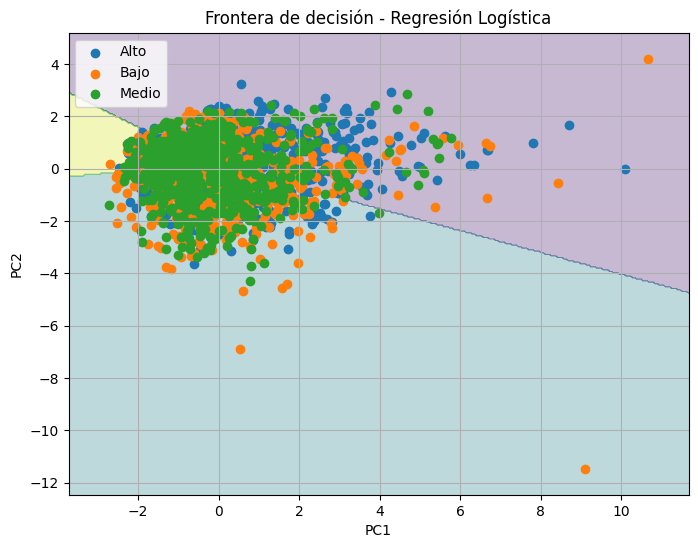

In [25]:
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

for i, clase in enumerate(le.classes_):
    mask = (y_encoded == i)
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=clase
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Frontera de decisión - Regresión Logística")
plt.legend()
plt.grid(True)
plt.show()

Como podemos observar, los resultados muestran un alto grado de solapamiento entre las clases, lo cual sugiere que el problema no es linealmente separable. Esto explica el desempeño del modelo de regresión logística, el cual se basa en fronteras de decisión lineales.

## 9. Conclusiones

La regresión logística multinomial permitió construir un modelo base para clasificar niveles de TCH y sacarosa a partir de variables agronómicas y de manejo. La estrategia de validación rigurosa, basada en una partición hold-out 80/20 y validación cruzada estratificada de 5 pliegues sobre entrenamiento, permitió seleccionar hiperparámetros de forma robusta y evitar sobreajuste.

En el caso de TCH, el modelo mostró un desempeño moderado, con mejores resultados en la clase "Alto" y mayores dificultades para clasificar la clase "Medio". Esto sugiere que las clases intermedias presentan mayor solapamiento en el espacio de características.

El análisis mediante PCA confirmó que las clases no son completamente separables, evidenciando un alto grado de solapamiento. Esto explica las limitaciones del modelo de regresión logística, el cual se basa en fronteras de decisión lineales.

Las variables más influyentes identificadas por el modelo muestran coherencia con el conocimiento agronómico del cultivo, particularmente en factores como edad, lluvias y variedad. No obstante, el desempeño observado indica que la estructura del problema podría requerir modelos no lineales.